# Uncontrolled plant with process noise

Same open-loop plant as the baseline, integrated with explicit forward-Euler so
that additive process noise can be injected on the velocity at each step. The
control input s is held at zero, this isolates how stochastic forcing alone
drives the state.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
A = np.array([
    [0.0, 1],            # position rate = 1 * velocity
    [-0.1, -0.1]         # velocity rate = stiffness + damping
])

B = np.array([           # spike-to-force map (unused here: s is held at 0)
    [0.0, 0.0],
    [2.0, -2.0]
])

def smd_dynamics(t, x, s):
    return A @ x + B @ s
    
T = 100                  # total simulated time (s)
dt = 0.01                # output sampling step
steps = int(T/dt)
noise_std = 0.1          # std of the additive process noise on velocity

x = np.zeros((2, steps))
x[:,0] = [2,0]           # initial state

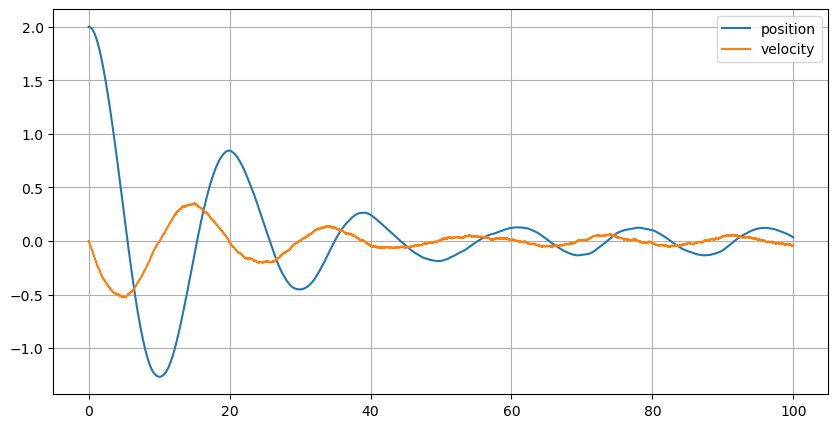

In [3]:
# Forward-Euler integration with additive Gaussian noise on the velocity channel
for i in range(steps-1):
    s = np.array([0,0])                # no control
    w = np.array([
    0,
    np.random.normal(0, noise_std)     # process noise (velocity only)
])
    dx = A @ x[:,i] + B @ s + w
    x[:,i+1] = x[:,i] + dt * dx        # Euler step

t = np.arange(steps) * dt

plt.figure(figsize=(10,5))
plt.plot(t, x[0], label="position")
plt.plot(t, x[1], label="velocity")
plt.legend()
plt.grid()
plt.show()